# Trend Detection with DBSCAN
DBSCAN clustering on TF-IDF text embeddings to find trending sub-topics within the `trending_topics` dataset.

## 1. Imports & Config

In [1]:
import os
os.makedirs("Results/DBSCAN", exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import DBSCAN
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score

from database_util import connect_database

sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42

## 2. Load Data from PostgreSQL

In [2]:
conn = connect_database()

cursor = conn.cursor()
cursor.execute("""
    SELECT id, text_en, topic, created_at, likes, retweets
    FROM trending_topics
    WHERE text_en IS NOT NULL
      AND TRIM(text_en) != ''
""")
rows = cursor.fetchall()
cols = [desc[0] for desc in cursor.description]
df = pd.DataFrame(rows, columns=cols)
cursor.close()

df["created_at"] = pd.to_datetime(df["created_at"])
df["likes"]    = df["likes"].fillna(0)
df["retweets"] = df["retweets"].fillna(0)
df["engagement"] = df["likes"] + df["retweets"]

print(f"Loaded {len(df):,} rows")
print(df["topic"].value_counts())

Loaded 10,233 rows
topic
Winter Olympics 2026 Milano    4881
Super Bowl LX                  4843
Politics                        509
Name: count, dtype: int64


## 3. Text Vectorisation (TF-IDF → SVD)

In [3]:
tfidf = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.85,
    sublinear_tf=True,
    stop_words="english"
)
X_tfidf = tfidf.fit_transform(df["text_en"])
print(f"TF-IDF shape: {X_tfidf.shape}")

N_COMPONENTS = 100
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_svd = svd.fit_transform(X_tfidf)
X_norm = normalize(X_svd)
print(f"SVD explained variance: {svd.explained_variance_ratio_.sum():.2%}")

TF-IDF shape: (10233, 8000)
SVD explained variance: 16.58%


## 4. Epsilon Tuning (k-distance plot)

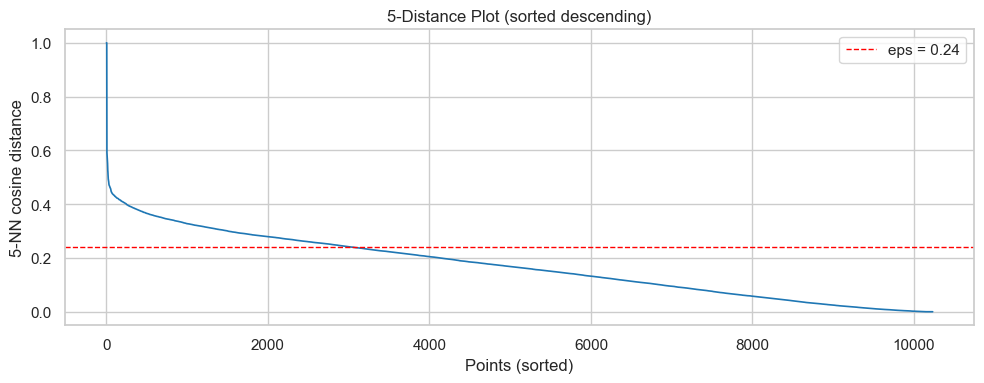

In [4]:
from sklearn.neighbors import NearestNeighbors

K = 5
nbrs = NearestNeighbors(n_neighbors=K, metric="cosine").fit(X_norm)
distances, _ = nbrs.kneighbors(X_norm)
k_distances = np.sort(distances[:, -1])[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_distances, linewidth=1.2)
ax.set_title(f"{K}-Distance Plot (sorted descending)")
ax.set_xlabel("Points (sorted)")
ax.set_ylabel(f"{K}-NN cosine distance")
ax.axhline(0.24, color="red", linestyle="--", linewidth=1, label="eps = 0.24")
ax.legend()
plt.tight_layout()
plt.savefig("Results/DBSCAN/dbscan_k_distance.png", bbox_inches="tight")
plt.show()

## 5. DBSCAN Clustering
Adjust  EPS for clustering

In [5]:
EPS     = 0.1
MIN_PTS = 5

dbscan = DBSCAN(eps=EPS, min_samples=MIN_PTS, metric="cosine", n_jobs=-1)
labels = dbscan.fit_predict(X_norm)

df["cluster"] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = (labels == -1).sum()
noise_pct  = n_noise / len(labels) * 100

print(f"Clusters found : {n_clusters}")
print(f"Noise points   : {n_noise:,} ({noise_pct:.1f}%)")
print(f"Clustered posts: {len(df) - n_noise:,}")

if n_clusters > 1:
    mask = labels != -1
    score = silhouette_score(X_norm[mask], labels[mask], metric="cosine", sample_size=3000)
    print(f"Silhouette score (excl. noise): {score:.4f}")

Clusters found : 180
Noise points   : 6,245 (61.0%)
Clustered posts: 3,988
Silhouette score (excl. noise): 0.6460


## 6. Cluster Sizes

C:\Users\rajib\AppData\Local\Temp\ipykernel_19680\3839870392.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cluster_counts.head(top_n), x="cluster", y="count",


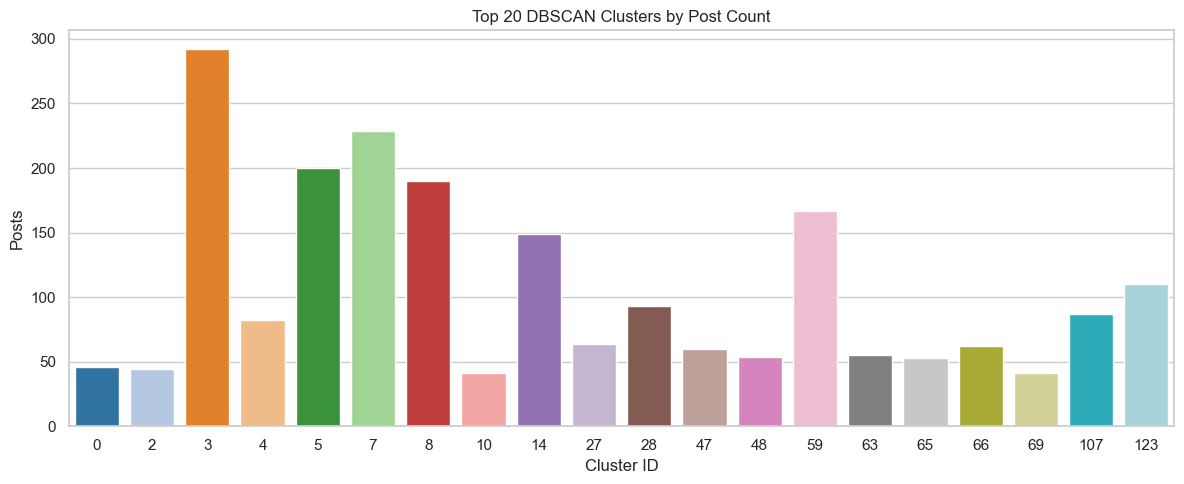

In [6]:
cluster_counts = (
    df[df["cluster"] != -1]
    .groupby("cluster")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

top_n = min(20, len(cluster_counts))
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=cluster_counts.head(top_n), x="cluster", y="count",
            palette="tab20", ax=ax)
ax.set_title(f"Top {top_n} DBSCAN Clusters by Post Count")
ax.set_xlabel("Cluster ID")
ax.set_ylabel("Posts")
plt.tight_layout()
plt.savefig("Results/DBSCAN/dbscan_cluster_sizes.png", bbox_inches="tight")
plt.show()

## 7. Cluster Keywords (Top TF-IDF Terms)

In [7]:
feature_names = tfidf.get_feature_names_out()
TOP_K_WORDS = 8

print(f"{'Cluster':>8}  {'Posts':>6}  Top Keywords")
print("=" * 80)

cluster_keywords = {}
for cid in cluster_counts["cluster"]:
    mask = (df["cluster"] == cid).values
    centroid = X_tfidf[mask].mean(axis=0)
    centroid = np.asarray(centroid).flatten()
    top_idx  = centroid.argsort()[::-1][:TOP_K_WORDS]
    keywords = ", ".join(feature_names[top_idx])
    cluster_keywords[cid] = keywords
    n = mask.sum()
    print(f"{cid:>8}  {n:>6}  {keywords}")

df["cluster_keywords"] = df["cluster"].map(cluster_keywords)

 Cluster   Posts  Top Keywords
       3     292  2026, purimfest, purimfest 2026, budget, allenanalysis, contest, racism, purim
       7     229  super, super woman, evil, sir, super clean, super hyped, hyped, woman
       5     200  2026 https, https, 2026, rt, welcome, welcome 2026, things, announced
       8     190  winter, https, rt, winter https, snow, gaza, florida, cold
      59     167  https, 2026, al, jersey https, trends, fc, office, high
      14     149  super bowl, bowl, super, https, mvp, watching, bowl mvp, bowl contenders
     123     110  bad, bunny, bad bunny, halftime, super bowl, bowl, bowl halftime, super
      28      93  cup, world cup, world, 2026 world, 2026, cup 2026, fifa, fifa world
     107      87  election, rt, uk, 2024 election, 2024, election https, general election, ukraine
       4      82  https, super, super impressive, impressive, soldier https, super obvious, super super, super agent
      27      64  rt, 2026, stuns 2026, open, happier, stuns, 

## 8. Topic Distribution per Cluster

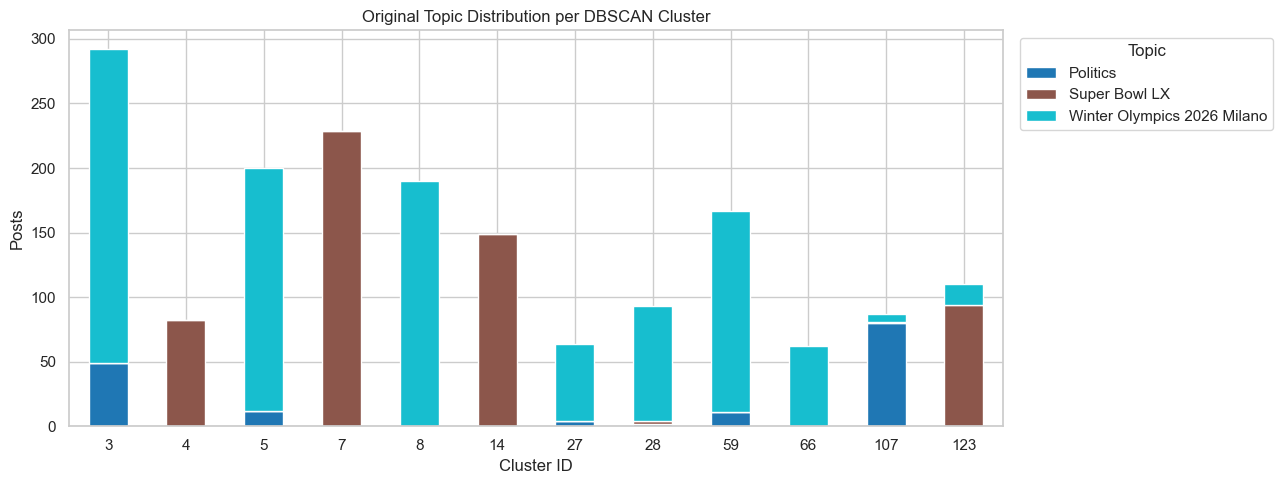

In [8]:
top_clusters = cluster_counts.head(12)["cluster"].tolist()
pivot = (
    df[df["cluster"].isin(top_clusters)]
    .groupby(["cluster", "topic"])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(13, 5))
pivot.plot(kind="bar", stacked=True, colormap="tab10", ax=ax)
ax.set_title("Original Topic Distribution per DBSCAN Cluster")
ax.set_xlabel("Cluster ID")
ax.set_ylabel("Posts")
ax.legend(title="Topic", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("Results/DBSCAN/dbscan_topic_distribution.png", bbox_inches="tight")
plt.show()

## 9. Engagement Analytics per Cluster

        Avg Engagement Median       Total
cluster                                  
59        75802.556886  251.0  12659027.0
5              22715.0   59.0   4543000.0
7         19553.615721   49.0   4477778.0
66         70532.66129  120.0   4373025.0
4         43181.134146  199.0   3540853.0
14         18452.52349  161.0   2749426.0
3          6656.472603   63.5   1943690.0
8          5838.347368   20.0   1109286.0
123        8119.545455   21.5    893150.0
28          8088.72043   32.0    752251.0
107        1701.827586   12.0    148059.0
27                 0.0    0.0         0.0


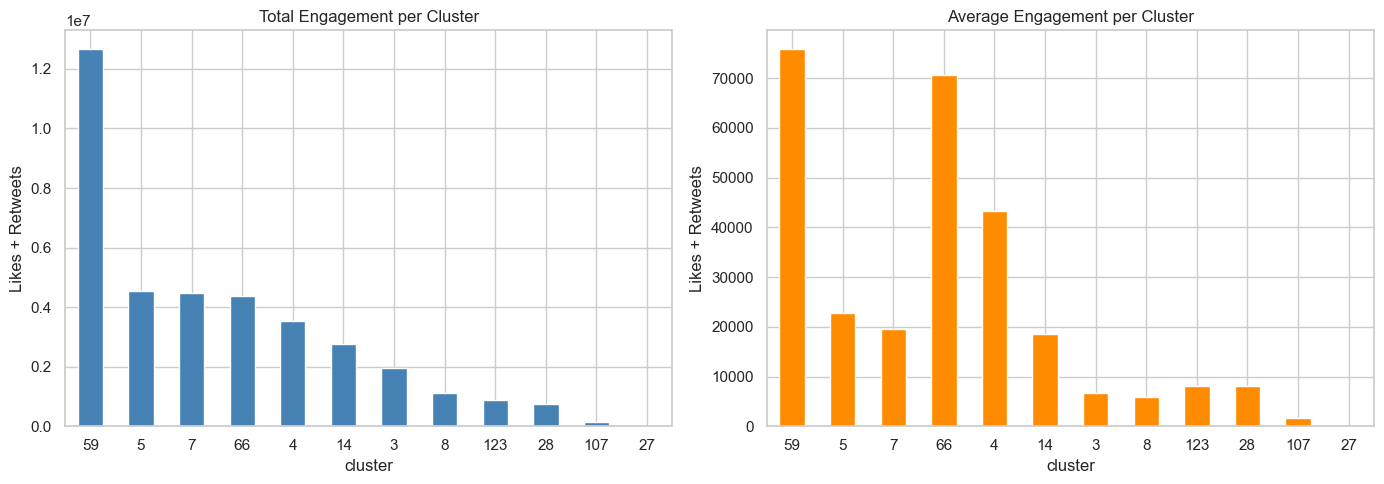

In [9]:
eng_stats = (
    df[df["cluster"].isin(top_clusters)]
    .groupby("cluster")["engagement"]
    .agg(["mean", "median", "sum"])
    .rename(columns={"mean": "Avg Engagement", "median": "Median", "sum": "Total"})
    .sort_values("Total", ascending=False)
)

print(eng_stats.round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

eng_stats["Total"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Total Engagement per Cluster")
axes[0].set_ylabel("Likes + Retweets")
axes[0].tick_params(axis="x", rotation=0)

eng_stats["Avg Engagement"].plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Average Engagement per Cluster")
axes[1].set_ylabel("Likes + Retweets")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("Results/DBSCAN/dbscan_engagement.png", bbox_inches="tight")
plt.show()

## 10. Cluster Activity Over Time

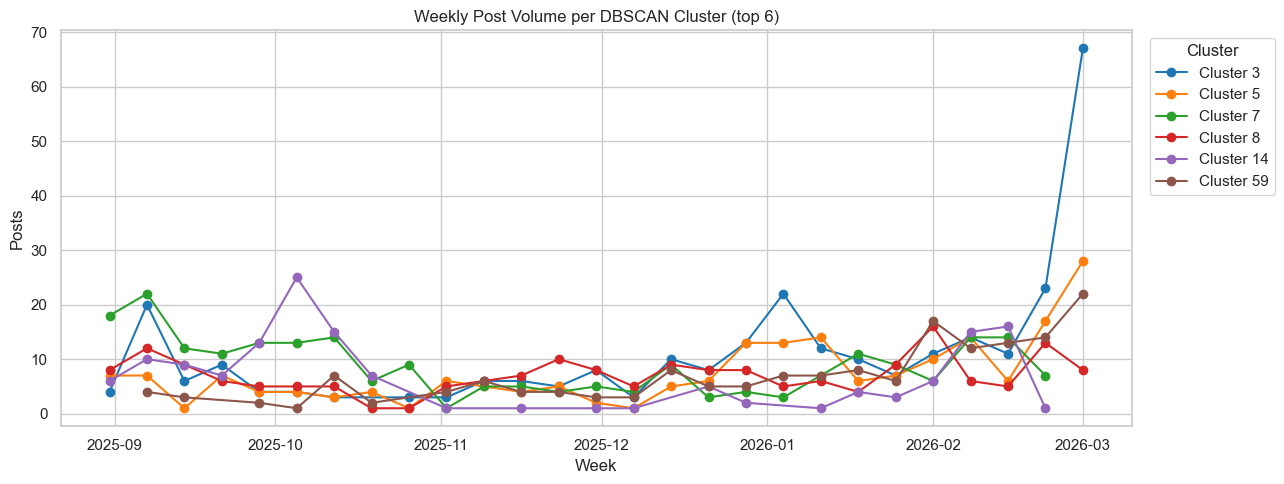

In [10]:
time_df = (
    df[df["cluster"].isin(top_clusters[:6])]
    .groupby([pd.Grouper(key="created_at", freq="W"), "cluster"])
    .size()
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=(13, 5))
for cid, grp in time_df.groupby("cluster"):
    ax.plot(grp["created_at"], grp["count"], marker="o", label=f"Cluster {cid}")

ax.set_title("Weekly Post Volume per DBSCAN Cluster (top 6)")
ax.set_xlabel("Week")
ax.set_ylabel("Posts")
ax.legend(title="Cluster", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.savefig("Results/DBSCAN/dbscan_time_series.png", bbox_inches="tight")
plt.show()

## 11. 2D Visualisation (SVD → 2 components)

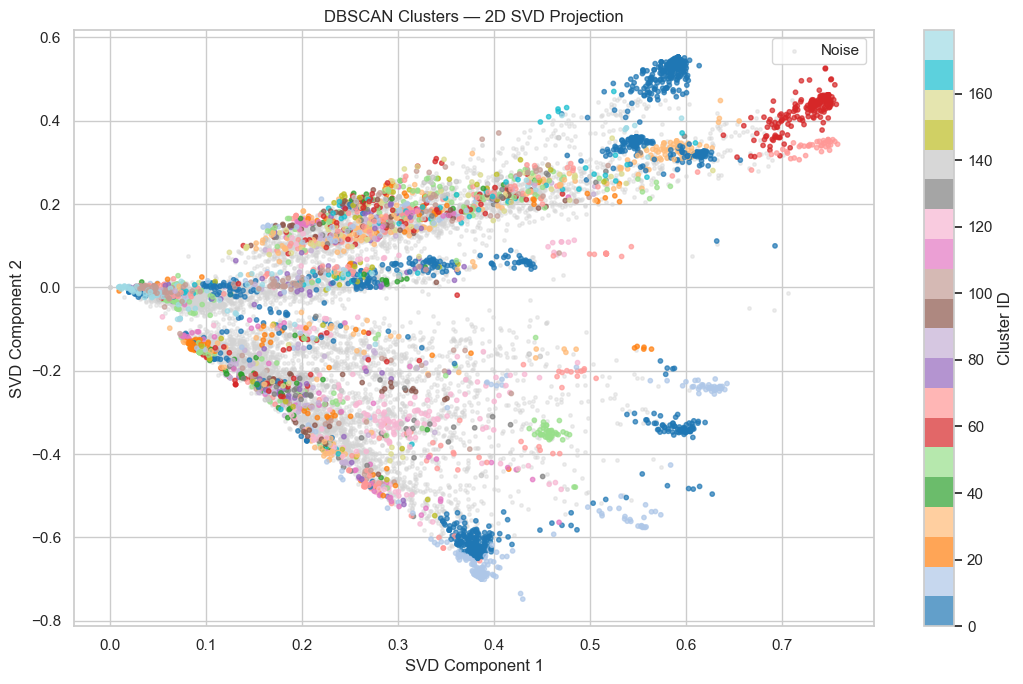

In [11]:
svd2 = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
X_2d = svd2.fit_transform(X_norm)

plot_df = pd.DataFrame({"x": X_2d[:, 0], "y": X_2d[:, 1], "cluster": labels})

noise_mask   = plot_df["cluster"] == -1
cluster_mask = ~noise_mask

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(plot_df.loc[noise_mask, "x"], plot_df.loc[noise_mask, "y"],
           c="lightgrey", s=6, alpha=0.4, label="Noise")

scatter = ax.scatter(
    plot_df.loc[cluster_mask, "x"],
    plot_df.loc[cluster_mask, "y"],
    c=plot_df.loc[cluster_mask, "cluster"],
    cmap="tab20", s=10, alpha=0.7
)
plt.colorbar(scatter, ax=ax, label="Cluster ID")
ax.set_title("DBSCAN Clusters — 2D SVD Projection")
ax.set_xlabel("SVD Component 1")
ax.set_ylabel("SVD Component 2")
ax.legend()
plt.tight_layout()
plt.savefig("Results/DBSCAN/dbscan_2d.png", bbox_inches="tight")
plt.show()

## 12. Summary Table — Top Clusters

In [12]:
summary = (
    df[df["cluster"] != -1]
    .groupby("cluster")
    .agg(
        posts=("id", "count"),
        avg_engagement=("engagement", "mean"),
        total_engagement=("engagement", "sum"),
        dominant_topic=("topic", lambda x: x.value_counts().index[0]),
        keywords=("cluster_keywords", "first")
    )
    .sort_values("posts", ascending=False)
    .head(15)
)

summary["avg_engagement"] = summary["avg_engagement"].round(1)
summary["total_engagement"] = summary["total_engagement"].astype(int)

print("\n── DBSCAN Cluster Summary ──")
print(summary.to_string())


── DBSCAN Cluster Summary ──
         posts avg_engagement  total_engagement               dominant_topic                                                                                                      keywords
cluster                                                                                                                                                                                   
3          292         6656.5           1943690  Winter Olympics 2026 Milano                                2026, purimfest, purimfest 2026, budget, allenanalysis, contest, racism, purim
7          229        19553.6           4477778                Super Bowl LX                                         super, super woman, evil, sir, super clean, super hyped, hyped, woman
5          200        22715.0           4543000  Winter Olympics 2026 Milano                                         2026 https, https, 2026, rt, welcome, welcome 2026, things, announced
8          190         5838.3      

## 13. Trend Report

In [13]:
report = (
    df[df["cluster"] != -1]
    .groupby("cluster")
    .agg(
        posts=("id", "count"),
        avg_engagement=("engagement", "mean"),
        total_engagement=("engagement", "sum"),
        dominant_topic=("topic", lambda x: x.value_counts().index[0]),
        first_seen=("created_at", "min"),
        last_seen=("created_at", "max"),
        keywords=("cluster_keywords", "first")
    )
    .sort_values("total_engagement", ascending=False)
    .reset_index()
)

report["avg_engagement"] = report["avg_engagement"].round(1)
report["total_engagement"] = report["total_engagement"].astype(int)

print("=" * 80)
print("EMERGING TRENDS REPORT")
print("=" * 80)
for _, row in report.iterrows():
    print(f"\n#{int(row['cluster'])} | {row['dominant_topic']}")
    print(f"   Keywords   : {row['keywords']}")
    print(f"   Posts      : {row['posts']}  |  Total Engagement: {row['total_engagement']}  |  Avg: {row['avg_engagement']}")
    print(f"   Active     : {row['first_seen'].date()} → {row['last_seen'].date()}")
print("\n" + "=" * 80)

report.to_csv("Results/DBSCAN/trend_report_dbscan.csv", index=False)

EMERGING TRENDS REPORT

#59 | Winter Olympics 2026 Milano
   Keywords   : https, 2026, al, jersey https, trends, fc, office, high
   Posts      : 167  |  Total Engagement: 12659027  |  Avg: 75802.6
   Active     : 2025-09-02 → 2026-03-01

#71 | Super Bowl LX
   Keywords   : bowl, https, maple, mascots, freestyle, pop, pepper, strawberries
   Posts      : 12  |  Total Engagement: 12094651  |  Avg: 1007887.6
   Active     : 2025-09-03 → 2025-11-20

#5 | Winter Olympics 2026 Milano
   Keywords   : 2026 https, https, 2026, rt, welcome, welcome 2026, things, announced
   Posts      : 200  |  Total Engagement: 4543000  |  Avg: 22715.0
   Active     : 2025-08-28 → 2026-03-01

#7 | Super Bowl LX
   Keywords   : super, super woman, evil, sir, super clean, super hyped, hyped, woman
   Posts      : 229  |  Total Engagement: 4477778  |  Avg: 19553.6
   Active     : 2025-08-28 → 2026-02-21

#66 | Winter Olympics 2026 Milano
   Keywords   : olympics, olympics https, milanocortina26, https, ioc, athl